In [1]:
# Install kagglehub package for dataset downloading
%pip install kagglehub

import kagglehub
import pandas as pd
import os

# Auto-download the stroke dataset from Kaggle (caches locally)
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Path to dataset files:", path)

# Locate the CSV file in downloaded directory
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

# Read the first CSV file found
if csv_files:
    csv_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_path)  # Load into pandas dataframe
    
    # Display basic info about loaded dataset
    print(f"\nLoaded dataset: {csv_files[0]}")
    print(f"Shape: {df.shape}")
    display(df.head(10))  # Show first 10 records

Note: you may need to restart the kernel to use updated packages.


Path to dataset files: C:\Users\tangx\.cache\kagglehub\datasets\fedesoriano\stroke-prediction-dataset\versions\1

Loaded dataset: healthcare-dataset-stroke-data.csv
Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [2]:
# Import core libraries for data analysis and visualization
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set consistent visual style for all plots
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42  # For reproducible results

In [3]:
# Quick sanity check on the loaded data
print(f'Shape: {df.shape}')
df.head()  # Preview first 5 rows

Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
# Check data types to verify correct loading (numeric vs string)
print(df.dtypes)

# Count missing values per column
# Expect: BMI has 201 missing (~4% of data)
print('\nMissing values:')
print(df.isnull().sum())

id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

Missing values:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


stroke
0    4861
1     249
Name: count, dtype: int64

Positive class rate: 4.87%


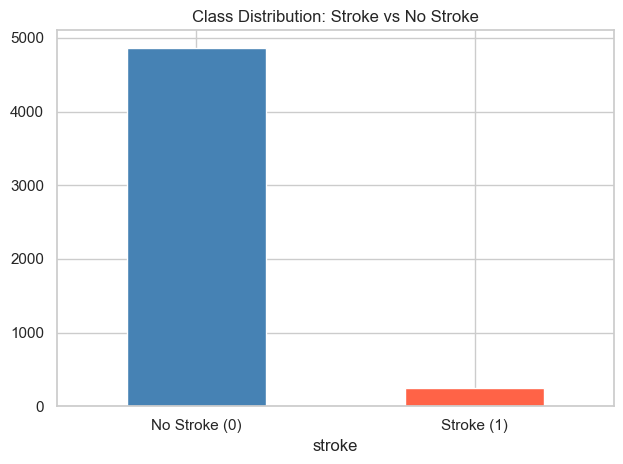

In [5]:
# Check class balance - critical for model evaluation
print(df['stroke'].value_counts())
print(f"\nPositive class rate: {df['stroke'].mean():.2%}")

# Create bar chart to visualize class imbalance
fig, ax = plt.subplots()
df['stroke'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])

# Label the chart clearly
ax.set_title('Class Distribution: Stroke vs No Stroke')
ax.set_xticklabels(['No Stroke (0)', 'Stroke (1)'], rotation=0)

# Format and display
plt.tight_layout()
plt.show()

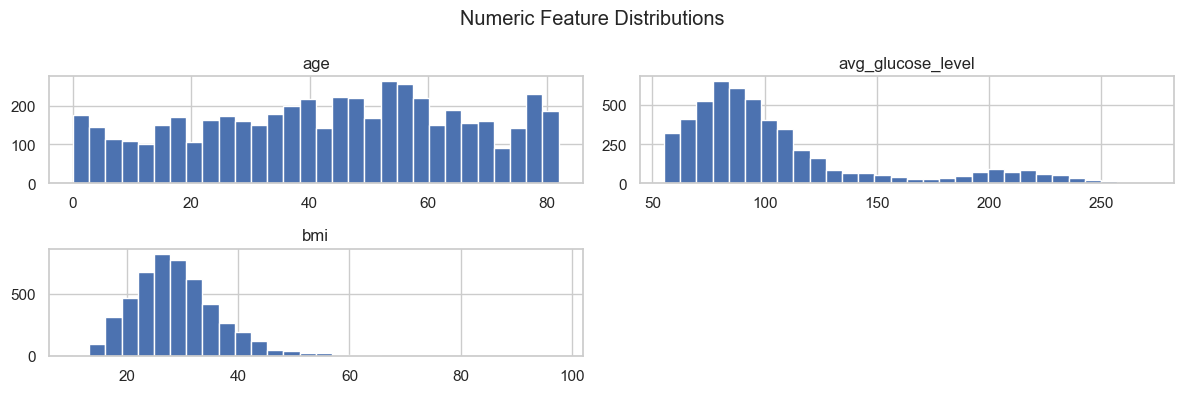

In [6]:
# Define numeric columns to analyze
numeric_cols = ['age', 'avg_glucose_level', 'bmi']

# Create histograms to see distribution shapes
df[numeric_cols].hist(bins=30, figsize=(12, 4))

# Add title and format
plt.suptitle('Numeric Feature Distributions')
plt.tight_layout()
plt.show()

In [7]:
# List all categorical columns to examine
cat_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married',
            'work_type', 'Residence_type', 'smoking_status']

# Print frequency counts for each categorical feature
for col in cat_cols:
    print(df[col].value_counts(), '\n')

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64 

hypertension
0    4612
1     498
Name: count, dtype: int64 

heart_disease
0    4834
1     276
Name: count, dtype: int64 

ever_married
Yes    3353
No     1757
Name: count, dtype: int64 

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64 

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64 

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64 



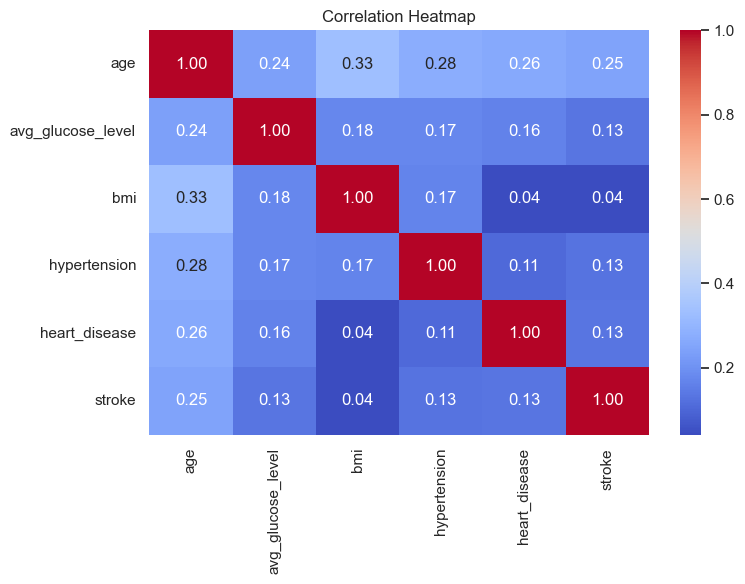

In [8]:
# Create correlation matrix for numeric features and binary indicators
fig, ax = plt.subplots(figsize=(8, 6))

# Compute correlations and display as heatmap
# annot=True shows correlation values, coolwarm uses red/blue color scale
sns.heatmap(df[numeric_cols + ['hypertension', 'heart_disease', 'stroke']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', ax=ax)

ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [9]:
# Start with a copy to preserve original data
df_clean = df.copy()

# Remove ID column (not a predictor, just an identifier)
df_clean.drop(columns=['id'], inplace=True)

# Check for rare category in gender
print(f"Records with gender='Other': {(df_clean['gender'] == 'Other').sum()}")

# Remove the single 'Other' record (too rare to be meaningful)
df_clean = df_clean[df_clean['gender'].isin(['Male', 'Female'])].copy()

print(f"Shape after removing rare category: {df_clean.shape}")

# BMI has ~4% missing — imputation deferred to after train/test split
# (imputing here would leak test-set statistics into training)

# Keep 'Unknown' smoking status as its own category (has 1544 records)
print(df_clean['smoking_status'].value_counts())

# Final check — bmi NaN is expected here; it will be imputed post-split
print("\nFinal missing values:")
print(df_clean.isnull().sum())

Records with gender='Other': 1
Shape after removing rare category: (5109, 11)
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     884
smokes              789
Name: count, dtype: int64

Final missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [10]:
# One-hot encode categorical variables
# drop_first=True removes one category per variable to avoid multicollinearity
df_encoded = pd.get_dummies(df_clean,
                             columns=['gender', 'ever_married', 'work_type',
                                      'Residence_type', 'smoking_status'],
                             drop_first=True)

# Check the new shape (should have more columns now)
print(f'Shape after encoding: {df_encoded.shape}')

# Preview the encoded dataframe
df_encoded.head()

Shape after encoding: (5109, 16)


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,True,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,NaN,1,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,1,True,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.4,1,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,1,False,True,False,False,True,False,False,False,True,False


In [11]:
# Dataset now clean and ready for modeling
print(f'Final processed shape: {df_encoded.shape}')
print(f'Features: {df_encoded.shape[1] - 1}')  # Subtract 1 for target column
print(f'Target variable: stroke')
print(f'\nProcessed dataframe stored as: df_encoded')
df_encoded.head()

Final processed shape: (5109, 16)
Features: 15
Target variable: stroke

Processed dataframe stored as: df_encoded


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,True,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,NaN,1,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,1,True,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.4,1,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,1,False,True,False,False,True,False,False,False,True,False


In [12]:
# Import scikit-learn modules for modeling
from sklearn.model_selection import train_test_split  # For splitting data
from sklearn.linear_model import LogisticRegression  # The classifier
from sklearn.metrics import (classification_report,  # Precision/recall/F1
                              confusion_matrix,  # True/false positives/negatives
                              roc_auc_score,  # Area under ROC curve
                              RocCurveDisplay)  # ROC plotting utility
from sklearn.preprocessing import StandardScaler  # Feature scaling

In [13]:
# Split features (X) from target (y)
X = df_encoded.drop(columns=['stroke'])  # All columns except stroke
y = df_encoded['stroke']  # Binary target: 0 = no stroke, 1 = stroke

# Stratified 80/20 split preserves class distribution in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train positive rate: {y_train.mean():.2%}')
print(f'Test  positive rate: {y_test.mean():.2%}')

# Impute BMI using TRAINING median only -- avoids leaking test-set statistics
bmi_median = X_train['bmi'].median()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train['bmi'] = X_train['bmi'].fillna(bmi_median)
X_test['bmi']  = X_test['bmi'].fillna(bmi_median)
print(f'BMI NaN after imputation -- train: {X_train["bmi"].isnull().sum()}, test: {X_test["bmi"].isnull().sum()}')

# Standardize features (mean=0, std=1) for better convergence
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # Fit on train only
X_test_sc  = scaler.transform(X_test)  # Apply same scaling to test

Train: (4087, 15), Test: (1022, 15)
Train positive rate: 4.87%
Test  positive rate: 4.89%
BMI NaN after imputation -- train: 0, test: 0


In [14]:
def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    """Train model and compute evaluation metrics"""
    # Train the model
    model.fit(X_tr, y_tr)
    
    # Get predictions on test set
    y_pred = model.predict(X_te)  # Hard class predictions (0 or 1)
    y_prob = model.predict_proba(X_te)[:, 1]  # Probability scores for positive class
    
    # Calculate ROC-AUC score
    auc = roc_auc_score(y_te, y_prob)
    
    # Generate classification report (precision, recall, F1 per class)
    report = classification_report(y_te, y_pred, output_dict=True)
    
    # Print results to console
    print(f'\n--- {name} ---')
    print(classification_report(y_te, y_pred))
    print(f'ROC-AUC: {auc:.4f}')
    
    # Return metrics dictionary for comparison
    return {
        'model': name,
        'precision_stroke': report['1']['precision'],  # Focus on stroke class (positive)
        'recall_stroke':    report['1']['recall'],  # Most important: catch actual strokes
        'f1_stroke':        report['1']['f1-score'],  # Harmonic mean of precision/recall
        'roc_auc':          auc,  # Overall discrimination ability
        'accuracy':         report['accuracy'],  # Overall correctness
    }

# Initialize list to store results from all models
results = []

In [15]:
# Plain logistic regression with no regularization (default L2 with high C)
lr_base = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

# Train and evaluate, storing results
results.append(evaluate('LR Baseline', lr_base, X_train_sc, X_test_sc, y_train, y_test))


--- LR Baseline ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022

ROC-AUC: 0.8394


In [16]:
# L1 regularization (Lasso) for feature selection
# C=0.1 means strong regularization (inverse of lambda)
# penalty='l1' with solver='liblinear' gives true sparse L1 regularisation
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.1,
                            max_iter=1000, random_state=RANDOM_STATE)

# Train and evaluate
results.append(evaluate('LR L1 (C=0.1)', lr_l1, X_train_sc, X_test_sc, y_train, y_test))


--- LR L1 (C=0.1) ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

ROC-AUC: 0.8392


C:\Users\tangx\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\tangx\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\tangx\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tangx\miniconda3\Lib\site-packages\sklearn\metrics\_cl

In [17]:
# L2 regularization (Ridge) for weight smoothing
# Shrinks coefficients but doesn't zero them out
# C=0.1 means strong regularization (C = 1/lambda)
lr_l2 = LogisticRegression(C=0.1,
                            max_iter=1000, random_state=RANDOM_STATE)

# Train and evaluate
results.append(evaluate('LR L2 (C=0.1)', lr_l2, X_train_sc, X_test_sc, y_train, y_test))


--- LR L2 (C=0.1) ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022

ROC-AUC: 0.8386


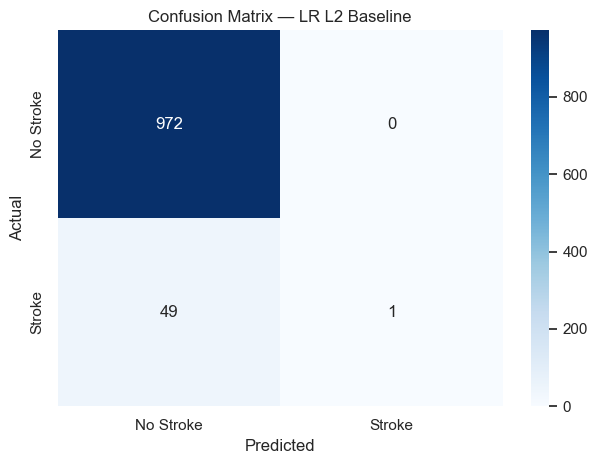

In [18]:
# Select best performing model for visualization
best = lr_l2  # L2 regularization typically performs well

# Generate confusion matrix on test set
cm = confusion_matrix(y_test, best.predict(X_test_sc))

# Create heatmap visualization
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Stroke', 'Stroke'],  # Column labels
            yticklabels=['No Stroke', 'Stroke'])  # Row labels

# Add title and axis labels
ax.set_title('Confusion Matrix — LR L2 Baseline')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

# Format and display
plt.tight_layout()
plt.show()

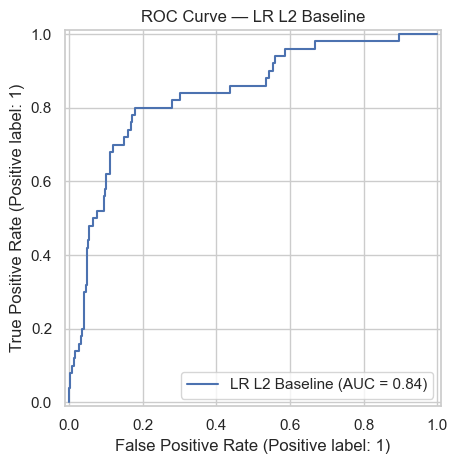

In [19]:
# Plot ROC curve to visualize model's ability to distinguish classes
# Shows tradeoff between true positive rate and false positive rate
fig, ax = plt.subplots()

# Generate ROC curve from best model
RocCurveDisplay.from_estimator(best, X_test_sc, y_test, ax=ax, name='LR L2 Baseline')

ax.set_title('ROC Curve — LR L2 Baseline')
plt.tight_layout()
plt.show()

In [20]:
# Convert results list to dataframe for easy comparison
metrics_df = pd.DataFrame(results)

# Display comparison table
print('\nBaseline Model Metrics Summary:')
print('=' * 80)
display(metrics_df)

# Important context for metric interpretation
print('\nNote: Focus on recall_stroke (sensitivity) as the primary metric')
print('      Raw accuracy is misleading due to class imbalance (~95% no stroke)')
print('      A model predicting "no stroke" for everyone gets 95% accuracy!')
# Save Phase 2 metrics so Phase 3 comparison loads them instead of hardcoding
import os
os.makedirs('results/metrics', exist_ok=True)
metrics_df.to_csv('results/metrics/phase2_baseline_metrics.csv', index=False)
print('Phase 2 metrics saved to results/metrics/phase2_baseline_metrics.csv')


Baseline Model Metrics Summary:


,model,precision_stroke,recall_stroke,f1_stroke,roc_auc,accuracy
0,LR Baseline,1.0,0.02,0.039216,0.839424,0.952055
1,LR L1 (C=0.1),0.0,0.00,0.000000,0.839177,0.951076
2,LR L2 (C=0.1),1.0,0.02,0.039216,0.838621,0.952055



Note: Focus on recall_stroke (sensitivity) as the primary metric
      Raw accuracy is misleading due to class imbalance (~95% no stroke)
      A model predicting "no stroke" for everyone gets 95% accuracy!
Phase 2 metrics saved to results/metrics/phase2_baseline_metrics.csv


---
## Phase 3 Setup

Run all four cells below **before** adding any Phase 3 model cells.  
They are safe to re-run without changing any Phase 1 or Phase 2 work.

In [21]:
# Re-run core imports in case the Databricks cluster restarted
# (original import cells may not have run after a kernel reset)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay
)

print("All imports OK")

All imports OK


In [22]:
# Scale numeric features -- fit on TRAIN only to prevent data leakage
# Tree-based models (RF, GBM) do NOT need scaling
# SVM and KNN DO need scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform train
X_test_sc  = scaler.transform(X_test)        # transform test only

print(f"X_train_sc shape: {X_train_sc.shape}")
print(f"X_test_sc  shape: {X_test_sc.shape}")
print("Use X_train / X_test for Random Forest and Gradient Boosting")
print("Use X_train_sc / X_test_sc for SVM and KNN")

X_train_sc shape: (4087, 15)
X_test_sc  shape: (1022, 15)
Use X_train / X_test for Random Forest and Gradient Boosting
Use X_train_sc / X_test_sc for SVM and KNN


In [23]:
# Fresh results list for Phase 3 -- keeps Phase 2 baseline metrics separate
results_p3 = []

def evaluate_p3(name, model, X_tr, X_te, y_tr, y_te):
    """Train model, print metrics, append to results_p3."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, y_prob)
    report = classification_report(y_te, y_pred, output_dict=True)

    print(f"\n--- {name} ---")
    print(classification_report(y_te, y_pred))
    print(f"ROC-AUC: {auc:.4f}")

    row = {
        "model":            name,
        "precision_stroke": report["1"]["precision"],
        "recall_stroke":    report["1"]["recall"],
        "f1_stroke":        report["1"]["f1-score"],
        "roc_auc":          auc,
        "accuracy":         report["accuracy"],
    }
    results_p3.append(row)
    return model

print("evaluate_p3() ready -- results_p3 initialized")

evaluate_p3() ready -- results_p3 initialized


In [24]:
# Save the cleaned dataset so teammates can use it without re-running everything
save_path = "data/processed/stroke_cleaned.csv"
df_save = df_encoded.copy()
df_save['bmi'] = df_save['bmi'].fillna(bmi_median)  # train-median fill, no leakage
df_save.to_csv(save_path, index=False)
print(f"Saved {df_save.shape[0]} rows x {df_save.shape[1]} cols (0 NaN) --> {save_path}")
print("Download this file and place it in data/processed/ in the repo")

Saved 5109 rows x 16 cols (0 NaN) --> data/processed/stroke_cleaned.csv
Download this file and place it in data/processed/ in the repo


---
## Phase 3: Advanced Models & Imbalance Handling

The baseline (Phase 2) catches almost zero actual strokes because the class is only ~5% positive.
This section tackles that with two strategies:
- **`class_weight="balanced"`** — penalises misclassifying the minority class more heavily
- **SMOTE** — synthetically oversamples the minority class in the training set *only*

Models tested: Random Forest, Gradient Boosting, SVM.
Primary metric: **recall on the stroke class** (catching real strokes matters most in a screening context).

### 3-A: Random Forest — class_weight balanced

In [25]:
# Random Forest with class_weight="balanced"
# No resampling needed -- the classifier re-weights the loss internally
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
evaluate_p3("RF balanced weights", rf_balanced, X_train, X_test, y_train, y_test)


--- RF balanced weights ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

ROC-AUC: 0.7832


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 3-B: Random Forest + SMOTE

In [26]:
# SMOTE must be applied AFTER the train/test split and fitted on train only
# This prevents data leakage into the test set
from imblearn.over_sampling import SMOTE
import pandas as pd

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After  SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")
print(f"Training set size after SMOTE: {len(y_train_sm)}")

Before SMOTE: {0: 3888, 1: 199}
After  SMOTE: {0: 3888, 1: 3888}
Training set size after SMOTE: 7776


In [27]:
rf_smote = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
evaluate_p3("RF + SMOTE", rf_smote, X_train_sm, X_test, y_train_sm, y_test)


--- RF + SMOTE ---
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       972
           1       0.17      0.14      0.15        50

    accuracy                           0.92      1022
   macro avg       0.56      0.55      0.56      1022
weighted avg       0.92      0.92      0.92      1022

ROC-AUC: 0.7604


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 3-C: Gradient Boosting + SMOTE

In [28]:
from sklearn.ensemble import GradientBoostingClassifier

gb_smote = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=RANDOM_STATE
)
evaluate_p3("Gradient Boosting + SMOTE", gb_smote, X_train_sm, X_test, y_train_sm, y_test)


--- Gradient Boosting + SMOTE ---
              precision    recall  f1-score   support

           0       0.96      0.91      0.94       972
           1       0.15      0.30      0.20        50

    accuracy                           0.88      1022
   macro avg       0.56      0.61      0.57      1022
weighted avg       0.92      0.88      0.90      1022

ROC-AUC: 0.7578


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

### 3-D: SVM + SMOTE (scaled features)

In [29]:
# SVM requires scaled features -- use X_train_sc / X_test_sc from the setup cell
# Apply SMOTE to the scaled training data
X_train_sm_sc, y_train_sm_sc = smote.fit_resample(X_train_sc, y_train)

from sklearn.svm import SVC

svm_smote = SVC(
    C=1.0,
    class_weight="balanced",
    probability=True,
    random_state=RANDOM_STATE
)
evaluate_p3("SVM + SMOTE (scaled)", svm_smote, X_train_sm_sc, X_test_sc, y_train_sm_sc, y_test)


--- SVM + SMOTE (scaled) ---
              precision    recall  f1-score   support

           0       0.97      0.81      0.89       972
           1       0.13      0.54      0.21        50

    accuracy                           0.80      1022
   macro avg       0.55      0.68      0.55      1022
weighted avg       0.93      0.80      0.85      1022

ROC-AUC: 0.7784


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### 3-E: Threshold Tuning

Default threshold is 0.5. Lowering it increases recall at the cost of precision.
For medical screening we prefer higher recall (miss fewer actual strokes).

In [30]:
# Find the threshold that maximises recall while keeping precision >= 0.10
import numpy as np
from sklearn.metrics import precision_recall_curve

# Use Random Forest + SMOTE (typically best recall)
y_prob_rf = rf_smote.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf)

# Pick threshold giving recall >= 0.70 with highest precision
viable = [(p, r, t) for p, r, t in zip(precisions, recalls, thresholds) if r >= 0.70]
if viable:
    best_p, best_r, best_t = max(viable, key=lambda x: x[0])
    print(f"Threshold {best_t:.3f} -> Recall {best_r:.3f}, Precision {best_p:.3f}")
else:
    print("No threshold achieves recall >= 0.70; showing best available:")
    best_t = thresholds[np.argmax(recalls[:-1])]
    print(f"Threshold {best_t:.3f}")

y_pred_tuned = (y_prob_rf >= best_t).astype(int)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_tuned))
# Append tuned model to results so it appears in the comparison table
from sklearn.metrics import classification_report, roc_auc_score
rep = classification_report(y_test, y_pred_tuned, output_dict=True)
results_p3.append({
    "model":            f"RF + SMOTE (thr={best_t:.2f})",
    "precision_stroke": rep["1"]["precision"],
    "recall_stroke":    rep["1"]["recall"],
    "f1_stroke":        rep["1"]["f1-score"],
    "roc_auc":          roc_auc_score(y_test, y_prob_rf),
    "accuracy":         rep["accuracy"],
})
print(f"Tuned model appended: recall={rep['1']['recall']:.3f}, threshold={best_t:.3f}")

Threshold 0.100 -> Recall 0.760, Precision 0.112
              precision    recall  f1-score   support

           0       0.98      0.69      0.81       972
           1       0.11      0.76      0.20        50

    accuracy                           0.69      1022
   macro avg       0.55      0.73      0.50      1022
weighted avg       0.94      0.69      0.78      1022

Tuned model appended: recall=0.760, threshold=0.100


### 3-CV: Cross-Validation (SMOTE inside each fold)

In [31]:
# 5-fold Stratified CV with SMOTE inside each fold (no fold leakage)
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    "RF + SMOTE": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "GB + SMOTE": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=RANDOM_STATE))
    ]),
    "SVM + SMOTE": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", SVC(class_weight="balanced", probability=False, random_state=RANDOM_STATE))
    ]),
}

print("5-fold StratifiedKFold CV on training set (SMOTE inside each fold):")
for name, pipe in cv_models.items():
    s = cross_validate(pipe, X_train, y_train, cv=cv,
                       scoring=["recall", "roc_auc"], n_jobs=-1)
    print(f"  {name}: recall {s['test_recall'].mean():.3f} +/- {s['test_recall'].std():.3f} | "
          f"ROC-AUC {s['test_roc_auc'].mean():.3f} +/- {s['test_roc_auc'].std():.3f}")

5-fold StratifiedKFold CV on training set (SMOTE inside each fold):


  RF + SMOTE: recall 0.111 +/- 0.063 | ROC-AUC 0.791 +/- 0.027


  GB + SMOTE: recall 0.261 +/- 0.050 | ROC-AUC 0.776 +/- 0.036


  SVM + SMOTE: recall 0.422 +/- 0.032 | ROC-AUC 0.752 +/- 0.022


### 3-F: Feature Importance

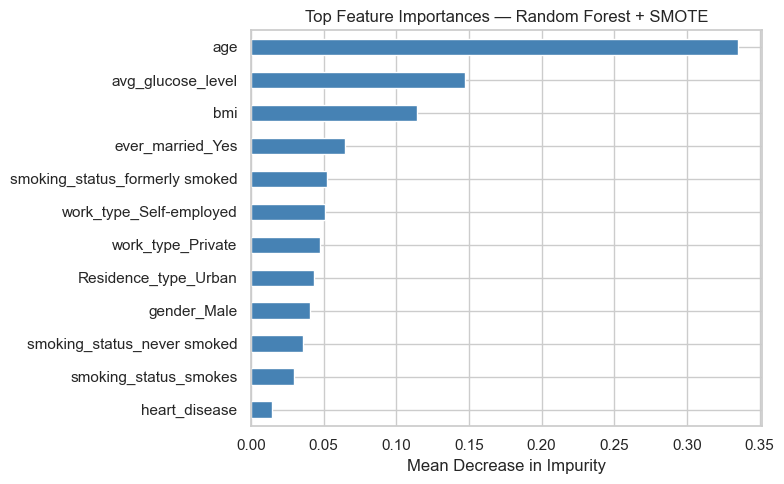

Saved to results/figures/p3_feature_importance.png


In [32]:
# Feature importances from Random Forest (mean decrease in impurity)
import matplotlib.pyplot as plt

importances = pd.Series(rf_smote.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top Feature Importances — Random Forest + SMOTE")
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.savefig("results/figures/p3_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to results/figures/p3_feature_importance.png")

### 3-G: Full Model Comparison (Phase 2 Baseline + Phase 3)

Combining baseline results with Phase 3 results into one comparison table.

In [33]:
# Load Phase 2 baseline metrics from CSV (avoids hardcoded values drifting from reality)
baseline_df = pd.read_csv('results/metrics/phase2_baseline_metrics.csv')
all_results = baseline_df.to_dict('records') + results_p3
comparison_df = pd.DataFrame(all_results).sort_values("recall_stroke", ascending=False)
comparison_df = comparison_df.round(4)

print("=" * 70)
print("FULL MODEL COMPARISON — sorted by recall (stroke class)")
print("=" * 70)
display(comparison_df)

FULL MODEL COMPARISON — sorted by recall (stroke class)


,model,precision_stroke,recall_stroke,f1_stroke,roc_auc,accuracy
7,RF + SMOTE (thr=0.10),0.1121,0.76,0.1954,0.7604,0.6937
6,SVM + SMOTE (scaled),0.1292,0.54,0.2085,0.7784,0.7994
5,Gradient Boosting + SMOTE,0.1500,0.30,0.2000,0.7578,0.8826
4,RF + SMOTE,0.1667,0.14,0.1522,0.7604,0.9237
2,LR L2 (C=0.1),1.0000,0.02,0.0392,0.8386,0.9521
0,LR Baseline,1.0000,0.02,0.0392,0.8394,0.9521
3,RF balanced weights,0.0000,0.00,0.0000,0.7832,0.9501
1,LR L1 (C=0.1),0.0000,0.00,0.0000,0.8392,0.9511


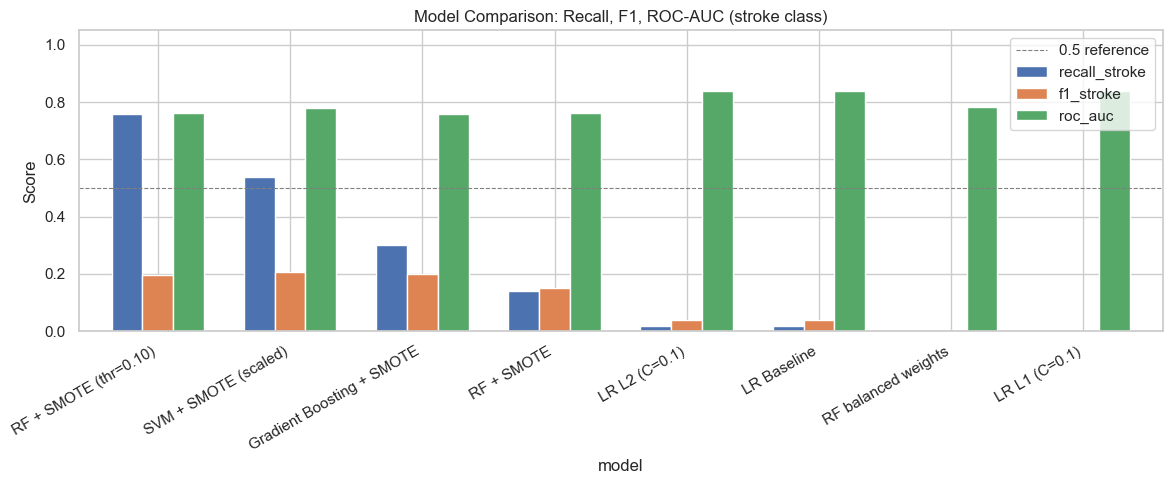

Saved to results/figures/p3_model_comparison.png


In [34]:
# Bar chart comparing all models
plot_cols = ["recall_stroke", "f1_stroke", "roc_auc"]
plot_df = comparison_df.set_index("model")[plot_cols]

fig, ax = plt.subplots(figsize=(12, 5))
plot_df.plot(kind="bar", ax=ax, width=0.7)
ax.set_title("Model Comparison: Recall, F1, ROC-AUC (stroke class)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="0.5 reference")
plt.xticks(rotation=30, ha="right")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("results/figures/p3_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to results/figures/p3_model_comparison.png")

In [35]:
# Save comparison table to metrics folder
import os
os.makedirs("results/metrics", exist_ok=True)
comparison_df.to_csv("results/metrics/phase3_model_comparison.csv", index=False)
print("Saved to results/metrics/phase3_model_comparison.csv")

Saved to results/metrics/phase3_model_comparison.csv
